Epoch 149/150
  Total:      0.0070
  Silhouette: 0.0018
  RGB:        0.0036
  Laplacian:  0.0047
  Edge:       0.0030
  Normal:     0.0388
  Color Sm:   0.0109
  LR:         0.005000


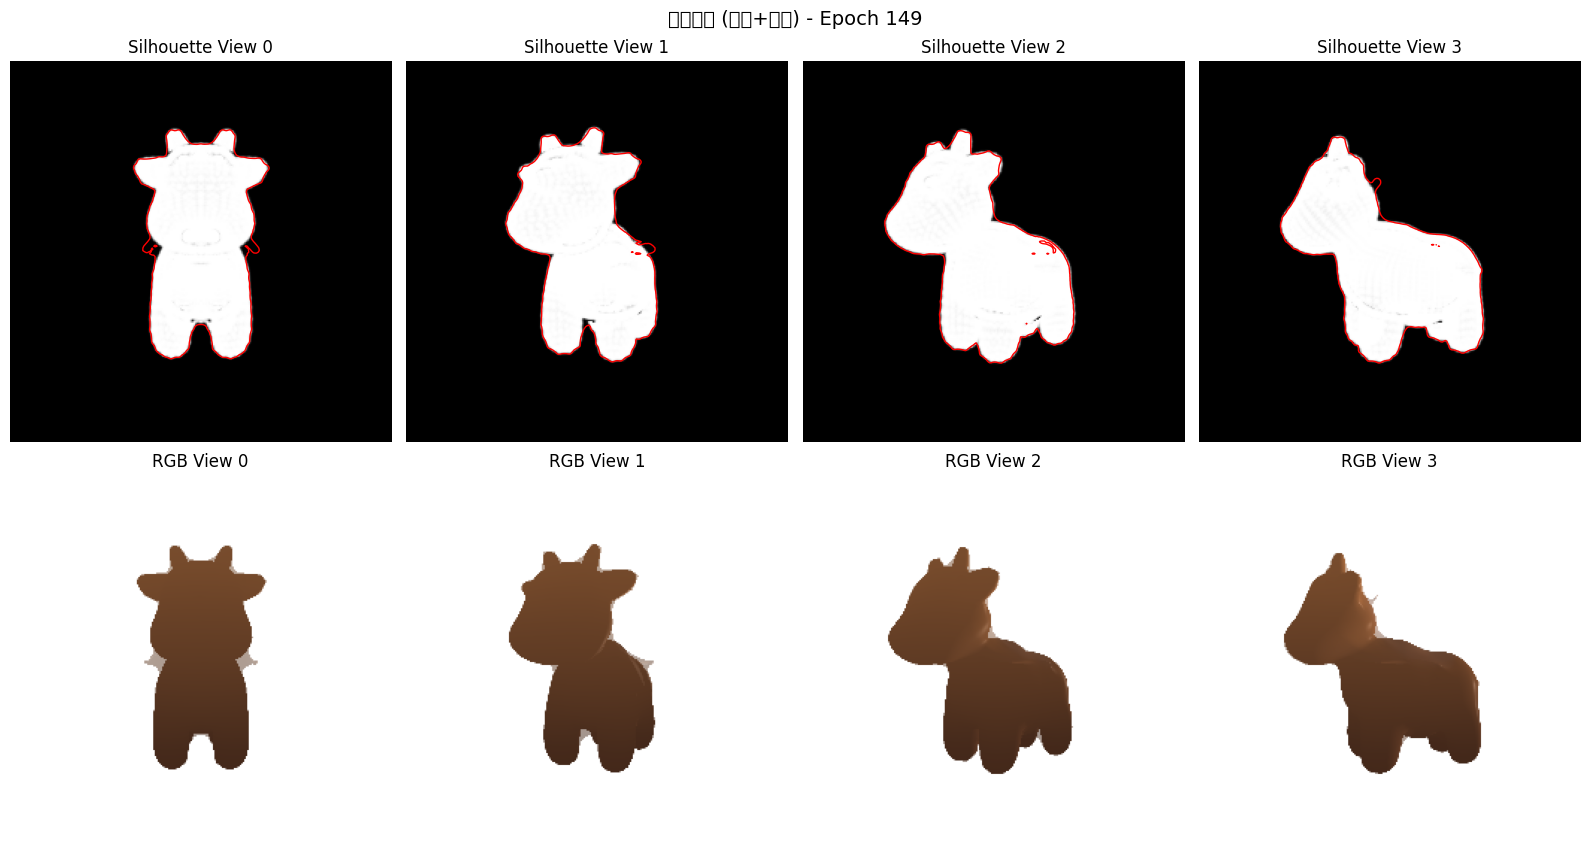


保存优化结果...
✅ 模型已保存: cow_textured_final.obj
✅ 顶点颜色已保存: cow_vertex_colors.npy (shape: torch.Size([2562, 3]))

渲染最终结果...


/tmp/ipykernel_15466/2904018621.py:378: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15466/2904018621.py:378: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15466/2904018621.py:378: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15466/2904018621.py:378: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15466/2904018621.py:378: UserWarning: Glyph 24425 (\N{CJK UNIFIED IDEOGRAPH-5F69}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15466/2904018621.py:378: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15466/2904018621.py:378: UserWarning: Glyph 22902 (\N{CJK UNIFIED I

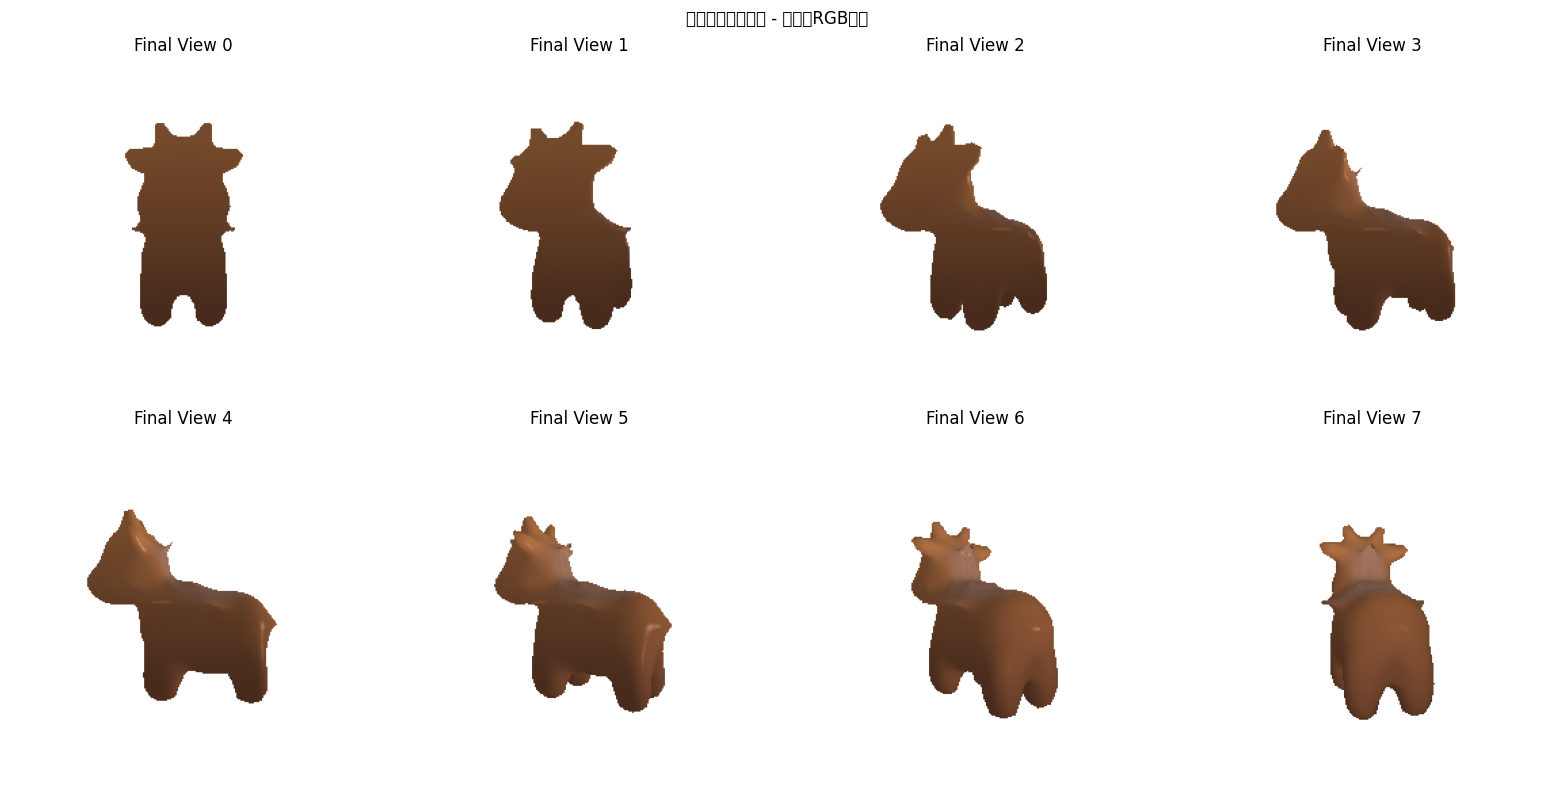


✅ 选做实验完成！
  最终顶点数: 2562
  最终面数: 5120
  颜色范围: [0.214, 0.916]

输出文件:
  - cow_textured_final.obj (带颜色的3D模型)
  - cow_vertex_colors.npy (顶点颜色数据)

💡 提示：
   - 可以使用 MeshLab 打开 cow_textured_final.obj 查看带颜色的模型
   - 在 MeshLab 中选择 'Render' → 'Show Vertex Color' 显示颜色


In [1]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.renderer import (
    SoftPhongShader, TexturesVertex, PointLights,
    RasterizationSettings, MeshRasterizer, SoftSilhouetteShader,
    BlendParams, look_at_view_transform, FoVPerspectiveCameras
)
from pytorch3d.loss import (
    mesh_laplacian_smoothing, mesh_edge_loss, mesh_normal_consistency
)

# 设置设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# ============================================
# 选做实验：同时优化形状和纹理（RGB监督）
# ============================================

class ShapeAndTextureOptimizer:
    def __init__(self, target_mesh, target_images, target_cameras):
        """
        同时优化形状和纹理
        target_mesh: 目标网格（带纹理）
        target_images: 多视角RGB图像 [num_views, H, W, 3]
        target_cameras: 摄像机参数
        """
        self.target_mesh = target_mesh
        self.target_images = target_images
        self.target_cameras = target_cameras
        self.num_views = target_images.shape[0]
        
        # 初始化源网格（细分球体）
        self.src_mesh = ico_sphere(4, device)
        print(f"源网格: {self.src_mesh.verts_packed().shape[0]} 个顶点, "
              f"{self.src_mesh.faces_packed().shape[0]} 个面")
        
        # 可优化参数1: 顶点偏移量（形状）
        self.deform_verts = torch.zeros_like(self.src_mesh.verts_packed(), 
                                             requires_grad=True)
        
        # 可优化参数2: 顶点颜色（纹理）
        init_colors = torch.ones_like(self.src_mesh.verts_packed()) * 0.5  # 初始灰色
        self.vertex_colors = torch.nn.Parameter(init_colors, requires_grad=True)
        
        # 剪影渲染器（软光栅化，用于形状监督）
        self.silhouette_rasterizer = MeshRasterizer(
            cameras=self.target_cameras,
            raster_settings=RasterizationSettings(
                image_size=256,
                blur_radius=np.log(1.0 / 1e-4 - 1.0) * 1e-4,
                faces_per_pixel=50
            )
        )
        self.silhouette_shader = SoftSilhouetteShader(
            blend_params=BlendParams(sigma=1e-4, gamma=1e-4)
        )
        
        # RGB渲染器（用于纹理监督）
        self.rgb_rasterizer = MeshRasterizer(
            cameras=self.target_cameras,
            raster_settings=RasterizationSettings(
                image_size=256,
                blur_radius=0.0,
                faces_per_pixel=1
            )
        )
        self.lights = PointLights(device=device, location=[[0.0, 0.0, 3.0]])
        self.rgb_shader = SoftPhongShader(
            device=device,
            cameras=self.target_cameras,
            lights=self.lights
        )
    
    def compute_loss(self, pred_silhouette, pred_rgb, mesh, epoch):
        """计算联合损失"""
        # 1. 形状损失（剪影）
        loss_silhouette = F.mse_loss(pred_silhouette, self.target_silhouettes)
        
        # 2. 纹理损失（RGB）
        pred_rgb_3ch = pred_rgb[..., :3]
        loss_rgb = F.l1_loss(pred_rgb_3ch, self.target_images)
        
        # 3. 正则化损失（防止网格变形过度）
        loss_laplacian = mesh_laplacian_smoothing(mesh)
        loss_edge = mesh_edge_loss(mesh)
        loss_normal = mesh_normal_consistency(mesh)
        
        # 4. 颜色平滑损失（相邻顶点颜色相近）
        edges = mesh.edges_packed()
        colors = self.vertex_colors
        color_diff = (colors[edges[:, 0]] - colors[edges[:, 1]]).norm(dim=1)
        loss_color_smooth = color_diff.mean()
        
        # 动态权重（前期重形状，后期重纹理）
        if epoch < 100:
            w_sil, w_rgb = 1.0, 0.3
            w_lap, w_edge, w_normal = 1.0, 0.1, 0.01
            w_color = 0.05
        elif epoch < 200:
            w_sil, w_rgb = 0.8, 0.5
            w_lap, w_edge, w_normal = 0.5, 0.05, 0.005
            w_color = 0.1
        else:
            w_sil, w_rgb = 0.5, 0.8
            w_lap, w_edge, w_normal = 0.3, 0.03, 0.003
            w_color = 0.2
        
        total_loss = (w_sil * loss_silhouette + 
                     w_rgb * loss_rgb +
                     w_lap * loss_laplacian +
                     w_edge * loss_edge +
                     w_normal * loss_normal +
                     w_color * loss_color_smooth)
        
        losses = {
            'silhouette': loss_silhouette.item(),
            'rgb': loss_rgb.item(),
            'laplacian': loss_laplacian.item(),
            'edge': loss_edge.item(),
            'normal': loss_normal.item(),
            'color_smooth': loss_color_smooth.item(),
            'total': total_loss.item()
        }
        
        return total_loss, losses
    
    def optimize(self, epochs=300, lr=0.01):
        """执行优化循环"""
        # 预先计算目标剪影（用于形状监督）
        print("准备目标剪影...")
        with torch.no_grad():
            fragments = self.silhouette_rasterizer(
                self.target_mesh.extend(self.num_views)
            )
            self.target_silhouettes = self.silhouette_shader(
                fragments, self.target_mesh.extend(self.num_views)
            )[..., 3]
        
        # 优化器
        optimizer = torch.optim.Adam(
            [self.deform_verts, self.vertex_colors], 
            lr=lr, betas=(0.9, 0.999)
        )
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
        
        print(f"\n开始联合优化（形状+纹理），共 {epochs} 轮...")
        print("-" * 60)
        
        for epoch in range(epochs):
            optimizer.zero_grad()
            
            # 1. 变形网格
            deformed_mesh = self.src_mesh.offset_verts(self.deform_verts)
            
            # 2. 添加纹理（顶点颜色）
            deformed_mesh.textures = TexturesVertex(verts_features=[self.vertex_colors])
            
            # 3. 渲染剪影
            sil_fragments = self.silhouette_rasterizer(
                deformed_mesh.extend(self.num_views)
            )
            pred_silhouette = self.silhouette_shader(
                sil_fragments, deformed_mesh.extend(self.num_views)
            )[..., 3]
            
            # 4. 渲染RGB图像
            rgb_fragments = self.rgb_rasterizer(
                deformed_mesh.extend(self.num_views)
            )
            pred_rgb = self.rgb_shader(rgb_fragments, deformed_mesh.extend(self.num_views))
            
            # 5. 计算损失
            loss, losses = self.compute_loss(pred_silhouette, pred_rgb, deformed_mesh, epoch)
            
            # 6. 反向传播
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            # 7. 可视化
            if epoch % 20 == 0 or epoch == epochs - 1:
                clear_output(wait=True)
                print(f"Epoch {epoch:3d}/{epochs}")
                print(f"  Total:      {losses['total']:.4f}")
                print(f"  Silhouette: {losses['silhouette']:.4f}")
                print(f"  RGB:        {losses['rgb']:.4f}")
                print(f"  Laplacian:  {losses['laplacian']:.4f}")
                print(f"  Edge:       {losses['edge']:.4f}")
                print(f"  Normal:     {losses['normal']:.4f}")
                print(f"  Color Sm:   {losses['color_smooth']:.4f}")
                print(f"  LR:         {scheduler.get_last_lr()[0]:.6f}")
                
                self.visualize(pred_silhouette, pred_rgb, epoch)
        
        # 返回优化后的网格
        final_mesh = self.src_mesh.offset_verts(self.deform_verts)
        final_mesh.textures = TexturesVertex(verts_features=[self.vertex_colors])
        return final_mesh
    
    def visualize(self, pred_silhouette, pred_rgb, epoch):
        """可视化优化过程"""
        fig, axes = plt.subplots(2, 4, figsize=(16, 9))
        
        # 第一行：剪影对比（目标 vs 预测轮廓）
        for i in range(4):
            axes[0, i].imshow(self.target_silhouettes[i].cpu().numpy(), cmap='gray')
            pred = pred_silhouette[i].cpu().detach().numpy()
            axes[0, i].contour(pred, levels=[0.5], colors='r', linewidths=1)
            axes[0, i].set_title(f"Silhouette View {i}")
            axes[0, i].axis('off')
        
        # 第二行：RGB对比（目标 vs 预测）
        for i in range(4):
            axes[1, i].imshow(self.target_images[i].cpu().numpy())
            pred = pred_rgb[i, ..., :3].cpu().detach().numpy()
            axes[1, i].imshow(pred, alpha=0.5)
            axes[1, i].set_title(f"RGB View {i}")
            axes[1, i].axis('off')
        
        plt.suptitle(f"联合优化 (形状+纹理) - Epoch {epoch}", fontsize=14)
        plt.tight_layout()
        plt.show()


# ============================================
# 准备目标数据（带纹理的RGB图像）
# ============================================

def prepare_target_rgb(obj_path, num_views=16):
    """从目标模型生成多视角RGB图像"""
    print(f"加载目标模型: {obj_path}")
    verts, faces, _ = load_obj(obj_path)
    faces_idx = faces.verts_idx.to(device)
    verts = verts.to(device)
    
    # 归一化到[-1, 1]范围
    verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0])
    
    # 创建目标网格
    target_mesh = Meshes(verts=[verts], faces=[faces_idx])
    
    # 为奶牛添加简单的颜色纹理（根据高度渐变）
    y_coords = verts[:, 1]
    colors = torch.zeros_like(verts)
    # 棕色系：底部深棕，顶部浅棕
    colors[:, 0] = 0.5 + 0.3 * (y_coords + 0.8)  # R
    colors[:, 1] = 0.3 + 0.2 * (y_coords + 0.8)  # G
    colors[:, 2] = 0.2 + 0.1 * (y_coords + 0.8)  # B
    colors = torch.clamp(colors, 0, 1)
    
    target_mesh.textures = TexturesVertex(verts_features=[colors])
    
    # 设置多视角摄像机
    print(f"设置 {num_views} 个摄像机视角...")
    cameras = FoVPerspectiveCameras(
        device=device,
        R=look_at_view_transform(2.7, torch.zeros(num_views), 
                                 torch.linspace(-180, 180, num_views))[0],
        T=look_at_view_transform(2.7, torch.zeros(num_views), 
                                 torch.linspace(-180, 180, num_views))[1]
    )
    
    # 渲染RGB图像
    print("渲染目标RGB图像...")
    rasterizer = MeshRasterizer(
        cameras=cameras,
        raster_settings=RasterizationSettings(image_size=256, blur_radius=0.0, faces_per_pixel=1)
    )
    lights = PointLights(device=device, location=[[0.0, 0.0, 3.0]])
    shader = SoftPhongShader(device=device, cameras=cameras, lights=lights)
    
    with torch.no_grad():
        fragments = rasterizer(target_mesh.extend(num_views))
        rgb_images = shader(fragments, target_mesh.extend(num_views))[..., :3]
    
    print(f"生成完成！RGB图像形状: {rgb_images.shape}")
    return target_mesh, rgb_images, cameras


# ============================================
# 保存带颜色的OBJ文件
# ============================================

def save_colored_obj(path, verts, faces, vertex_colors):
    """保存带顶点颜色的OBJ文件"""
    with open(path, 'w') as f:
        f.write("# Colored mesh\n")
        f.write(f"# Vertices: {len(verts)}, Faces: {len(faces)}\n\n")
        
        # 写入顶点坐标和颜色
        for v, c in zip(verts, vertex_colors):
            f.write(f"v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f} {c[0]:.6f} {c[1]:.6f} {c[2]:.6f}\n")
        
        # 写入面
        for face in faces:
            f.write(f"f {face[0]+1} {face[1]+1} {face[2]+1}\n")
    
    print(f"✅ 模型已保存: {path}")


# ============================================
# 主程序：运行选做实验
# ============================================

if __name__ == "__main__":
    print("=" * 60)
    print("选做实验：从球体优化为彩色奶牛（同时优化形状和颜色）")
    print("=" * 60)
    
    # 1. 检查文件
    obj_path = "cow.obj"
    if not os.path.exists(obj_path):
        raise FileNotFoundError(f"找不到 {obj_path}，请确保文件存在")
    
    # 2. 准备目标数据（生成多视角RGB图像）
    target_mesh, target_images, cameras = prepare_target_rgb(obj_path, num_views=16)
    
    # 3. 显示目标RGB图像示例
    print("\n显示目标多视角RGB图像...")
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i in range(min(8, target_images.shape[0])):
        row, col = i // 4, i % 4
        axes[row, col].imshow(target_images[i].cpu().numpy())
        axes[row, col].set_title(f"View {i}")
        axes[row, col].axis('off')
    plt.suptitle("目标多视角RGB图像（Ground Truth - 奶牛）")
    plt.tight_layout()
    plt.show()
    
    # 4. 创建优化器并运行
    print("\n初始化优化器...")
    optimizer = ShapeAndTextureOptimizer(target_mesh, target_images, cameras)
    
    # 5. 执行优化（先用150轮测试，成功后可改为300）
    final_mesh = optimizer.optimize(epochs=150, lr=0.01)
    
    # 6. 保存结果
    print("\n" + "=" * 60)
    print("保存优化结果...")
    
    verts_final = final_mesh.verts_list()[0].cpu()
    faces_final = final_mesh.faces_list()[0].cpu()
    colors_final = optimizer.vertex_colors.detach().cpu()
    
    # 保存带颜色的OBJ
    save_colored_obj("cow_textured_final.obj", verts_final, faces_final, colors_final)
    
    # 保存颜色数据为numpy格式
    np.save("cow_vertex_colors.npy", colors_final.numpy())
    print(f"✅ 顶点颜色已保存: cow_vertex_colors.npy (shape: {colors_final.shape})")
    
    # 7. 最终结果可视化
    print("\n渲染最终结果...")
    with torch.no_grad():
        rasterizer_final = MeshRasterizer(
            cameras=cameras,
            raster_settings=RasterizationSettings(image_size=256, blur_radius=0.0, faces_per_pixel=1)
        )
        final_mesh_extended = final_mesh.extend(16)
        fragments = rasterizer_final(final_mesh_extended)
        final_rgb = optimizer.rgb_shader(fragments, final_mesh_extended)
        
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        for i in range(min(8, 16)):
            row, col = i // 4, i % 4
            axes[row, col].imshow(final_rgb[i, ..., :3].cpu().numpy())
            axes[row, col].set_title(f"Final View {i}")
            axes[row, col].axis('off')
        plt.suptitle("优化后的彩色奶牛 - 多视角RGB图像")
        plt.tight_layout()
        plt.show()
    
    # 8. 打印统计信息
    print("\n" + "=" * 60)
    print("✅ 选做实验完成！")
    print(f"  最终顶点数: {len(verts_final)}")
    print(f"  最终面数: {len(faces_final)}")
    print(f"  颜色范围: [{colors_final.min():.3f}, {colors_final.max():.3f}]")
    print("\n输出文件:")
    print("  - cow_textured_final.obj (带颜色的3D模型)")
    print("  - cow_vertex_colors.npy (顶点颜色数据)")
    print("=" * 60)
    
    # 9. 显示3D模型预览提示
    print("\n💡 提示：")
    print("   - 可以使用 MeshLab 打开 cow_textured_final.obj 查看带颜色的模型")
    print("   - 在 MeshLab 中选择 'Render' → 'Show Vertex Color' 显示颜色")